# **Load the preprocessed dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("Preprocessed_dataset.csv", delimiter=',')
print("Shape:", df.shape)
df.head()

Shape: (23535, 100)


,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,age_binned,hours_binned
0,1.000000,77053,9,0,0.0,1.000000,0.368421,<=50K,False,False,...,False,False,False,False,False,True,False,False,3.0,1.0
1,0.671233,186061,10,0,0.0,1.000000,0.368421,<=50K,False,False,...,False,False,False,False,False,True,False,False,2.0,1.0
2,0.506849,140359,4,0,0.0,0.895317,0.368421,<=50K,False,False,...,False,False,False,False,False,True,False,False,2.0,1.0
3,0.328767,264663,10,0,0.0,0.895317,0.368421,<=50K,False,False,...,False,False,False,False,False,True,False,False,1.0,1.0
4,0.232877,216864,9,0,0.0,0.865473,0.631579,<=50K,False,False,...,False,False,False,False,False,True,False,False,0.0,2.0


# **Identify features (X) and target (y)**

In [ ]:
# Robust target detection
target_col = "income" # Directly specify the target column name

# Print column names to diagnose
print("Columns in dataframe:", df.columns.tolist())

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")


print("Detected target column:", target_col)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Map strings to numeric if needed
if y.dtype == object:
    y = y.astype(str).str.strip()
    if set(y.unique()) <= {">50K", "<=50K"}:
        y = y.map({"<=50K": 0, ">50K": 1})
    elif set(y.unique()) <= {"1", "0"}:
        y = y.astype(int)
    else:
        # Generic factorize for unseen labels
        y, _ = pd.factorize(y)

print("y classes:", sorted(pd.Series(y).unique()))
print("Feature count:", X.shape[1])

Columns in dataframe: ['age', 'fnlwgt', 'education.num', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'income', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'educatio

# **Train/Test splits + Gini Decision Tree**

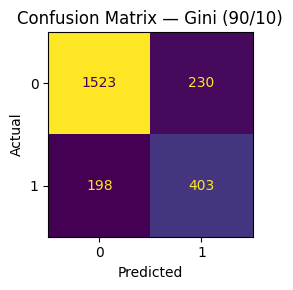

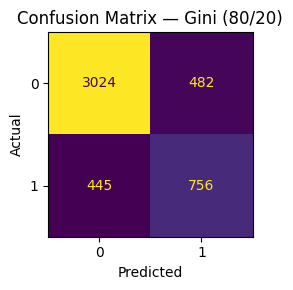

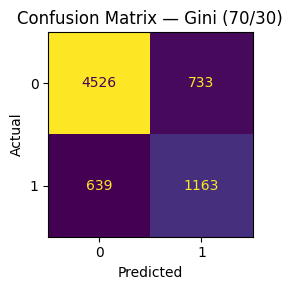

[('90/10',
  0.8181818181818182,
  0.8215571757516675,
  0.8181818181818182,
  0.8197018768058648),
 ('80/20',
  0.8030592734225621,
  0.8051113592821312,
  0.8030592734225621,
  0.804030732023844),
 ('70/30',
  0.8056932445829202,
  0.8091929313767968,
  0.8056932445829202,
  0.807286705115816)]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

splits = [(0.1, "90/10"), (0.2, "80/20"), (0.3, "70/30")]
results_gini = []
trained_models = {}

for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    clf = DecisionTreeClassifier(criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Store the trained model and test/prediction data
    trained_models[label] = (clf, X_test, y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results_gini.append((label, acc, prec, rec, f1))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(4,3))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — Gini ({label})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

results_gini

# **Results table (Accuracy, Precision, Recall, F1)**

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results_gini, columns=["Split", "Accuracy", "Precision", "Recall", "F1-Score"])
order = {"90/10":0, "80/20":1, "70/30":2}
results_df["order"] = results_df["Split"].map(order)
results_df = results_df.sort_values("order").drop(columns="order").reset_index(drop=True)
results_df

,Split,Accuracy,Precision,Recall,F1-Score
0,90/10,0.818182,0.821557,0.818182,0.819702
1,80/20,0.803059,0.805111,0.803059,0.804031
2,70/30,0.805693,0.809193,0.805693,0.807287


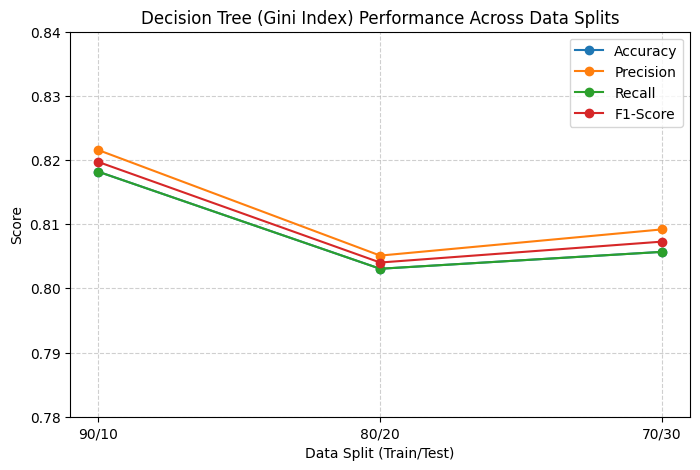

In [ ]:
import matplotlib.pyplot as plt

# Plotting the comparison
plt.figure(figsize=(8,5))
plt.plot(results_df["Split"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Split"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Split"], results_df["Recall"], marker='o', label="Recall")
plt.plot(results_df["Split"], results_df["F1-Score"], marker='o', label="F1-Score")

plt.title("Decision Tree (Gini Index) Performance Across Data Splits")
plt.xlabel("Data Split (Train/Test)")
plt.ylabel("Score")
plt.ylim(0.78, 0.84)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

- The plot shows a slight decrease in all metrics as the test size increases, which is consistent with expectations — less training data typically reduces model accuracy.
- The small performance gap between the splits demonstrates good model stability and generalization.
- The overlapping metric curves (Accuracy ≈ Precision ≈ Recall ≈ F1) further confirm that the model’s predictions are balanced and consistent across both classes.

# **Visualize decision trees (Gini)**

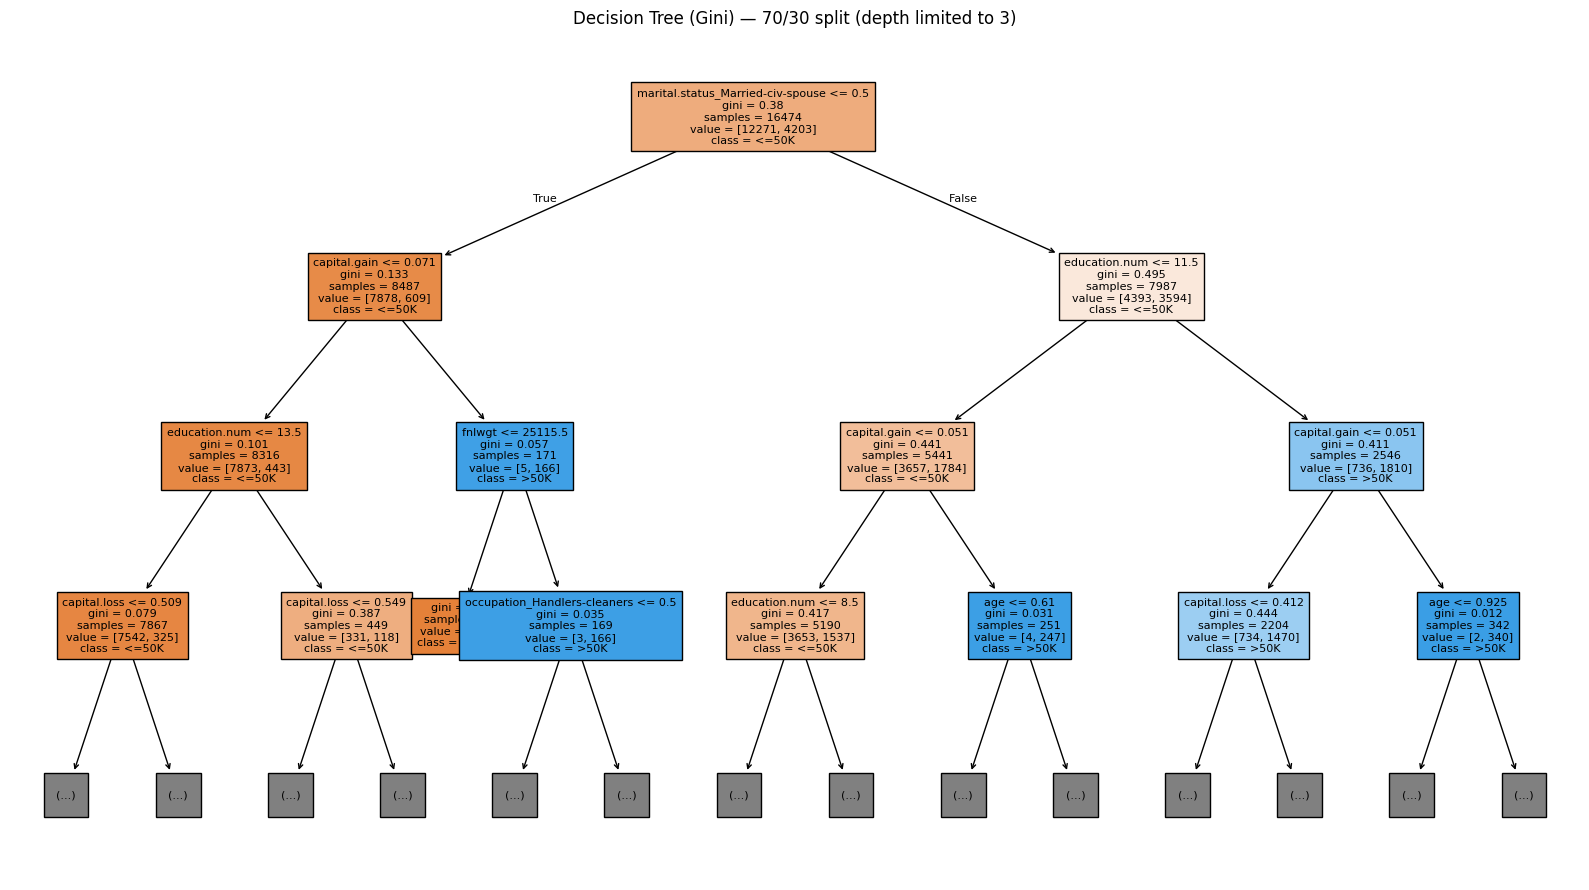

In [ ]:
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt

label_to_plot = "70/30"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

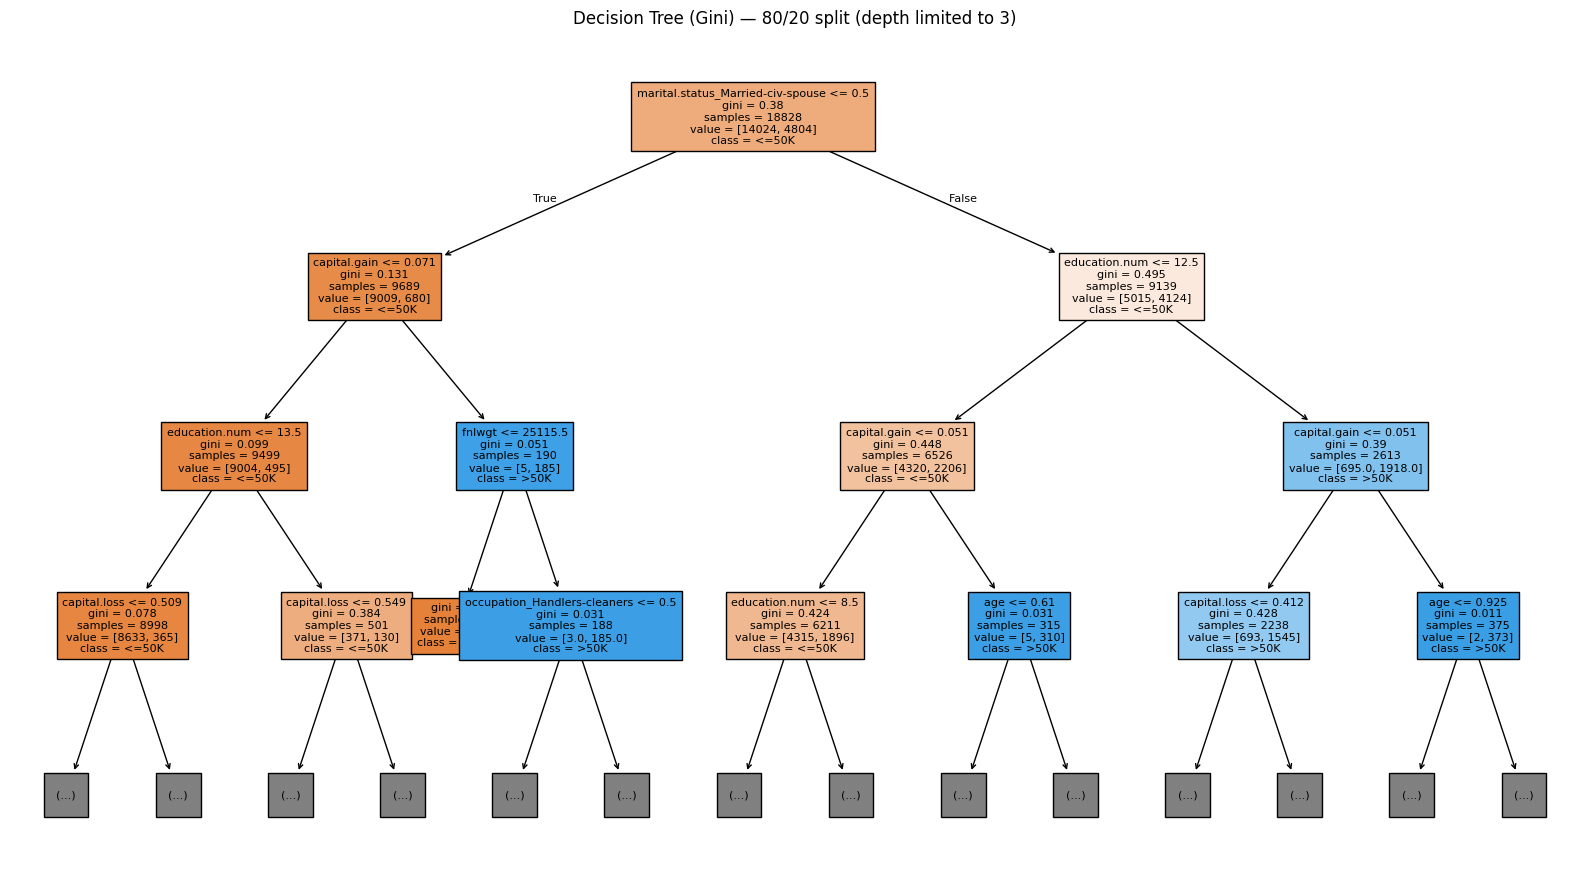

In [ ]:
label_to_plot = "80/20"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

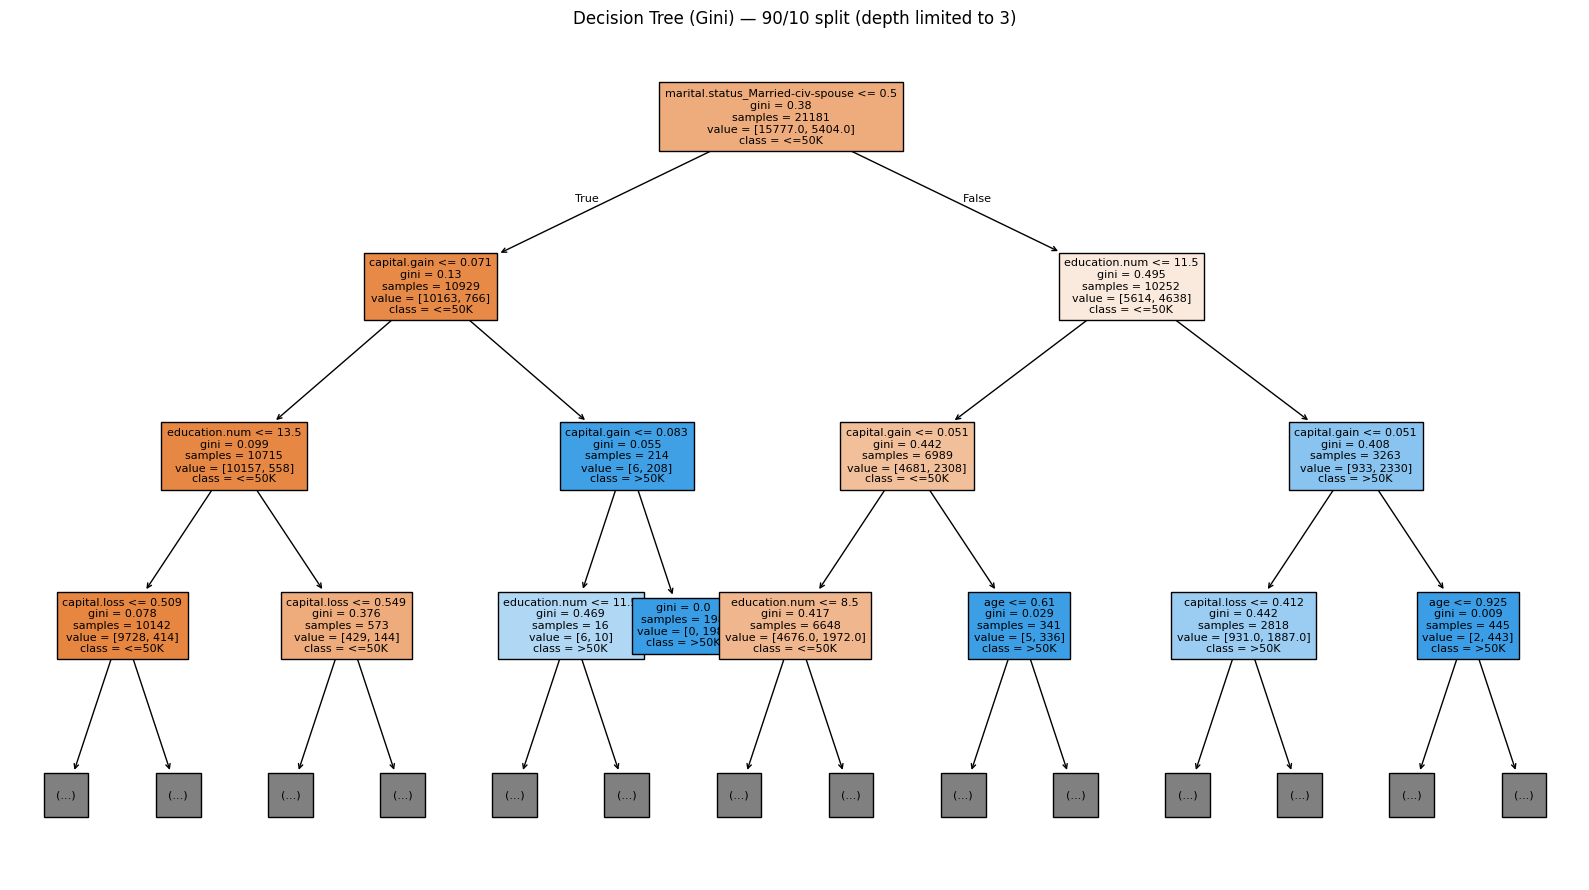

In [ ]:
label_to_plot = "90/10"
if label_to_plot not in trained_models:
    label_to_plot = list(trained_models.keys())[-1]

# Unpack all four values: clf, X_test, y_test, y_pred
clf_to_plot, X_test_plot, y_test_plot, y_pred_plot = trained_models[label_to_plot]

unique_classes = np.unique(y)
class_names = ["<=50K", ">50K"] if set(unique_classes) == {0,1} else [str(c) for c in unique_classes]

plt.figure(figsize=(16,9))
tree.plot_tree(
    clf_to_plot,
    filled=True,
    feature_names=X_test_plot.columns.tolist(), # Use X_test_plot for feature names
    class_names=class_names,
    max_depth=3,   # limit depth for readability
    fontsize=8
)
plt.title(f"Decision Tree (Gini) — {label_to_plot} split (depth limited to 3)")
plt.tight_layout()
plt.show()

# **Comparison & Discussion**

The Decision Tree classifier using the Gini Index achieved consistent and reliable performance across all three data partitions.

**Performance Comparison**
- The highest accuracy (81.8%) was achieved with the 90/10 split, where more data was used for training.
- As expected, accuracy slightly decreased with larger test sizes (80/20 → 80.3%, 70/30 → 80.6%), which is normal since the model has fewer training samples.
- The similarity between precision, recall, and F1 across all splits indicates balanced classification performance — the model is not heavily biased toward one income class.
- The stability of results suggests that the Decision Tree generalizes well and does not overfit severely despite being trained on different data proportions.

**Confusion Matrix Interpretation**
- The confusion matrices show that the model correctly classifies a majority of low-income (≤50K) individuals (top-left cell) with some misclassification of high-income (>50K) as low-income (bottom-left cell).
- For example, in the 80/20 split:
1) 3,024 people earning ≤50K were correctly classified, while 482 were incorrectly labeled as >50K.

2) 756 high-income individuals were correctly identified, but 445 were misclassified.
- This pattern reveals a class imbalance effect — the dataset contains more low-income samples, making the model slightly better at recognizing that class.
- Still, the reasonable F1-scores (~0.81) confirm the model handles both classes fairly well.

**Visual Representation and Feature Insights**

From the decision tree visualizations (depth limited to 3), the most influential features are:
- Marital status (Married-civ-spouse) — the primary splitting feature, strongly associated with income level.
- Capital gain, education level, and occupation — secondary predictors that refine income classification.
- Individuals with higher capital gain and education level tend to belong to the >50K class, while those with lower values and “non-married” marital status are often in the ≤50K class.

The visual structure of the tree clearly reflects human-interpretable decision logic, demonstrating why Decision Trees are useful for exploratory analysis and transparent model behavior.

**Overall Interpretation**
- The model’s performance is consistent across different splits, suggesting robustness.
- Slightly higher precision than recall indicates the classifier is cautious in labeling someone as high-income (fewer false positives).
- The main limitations arise from class imbalance and potential overfitting if the full-depth tree were used.
- Future improvements could include pruning, balancing classes, or using ensemble methods (Random Forest) for enhanced generalization.